<a href="https://www.kaggle.com/code/vidushigupta1/brainstrokeprediction?scriptVersionId=327461833" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [8]:
!pip install torch torchvision --quiet
import subprocess
subprocess.run(["pip", "install", "torch", "--quiet"])

CompletedProcess(args=['pip', 'install', 'torch', '--quiet'], returncode=0)

In [9]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import os

# Step 2: Find the dataset path
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/cerebral-stroke-predictionimbalaced-dataset/dataset.csv


In [10]:
# Step 3: Read the CSV
data = pd.read_csv("/kaggle/input/cerebral-stroke-predictionimbalaced-dataset/dataset.csv")

# Step 4: Basic info
print("Shape:", data.shape)
data.head()


Shape: (43400, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,30669,Male,3.0,0,0,No,children,Rural,95.12,18.0,NaN,0
1,30468,Male,58.0,1,0,Yes,Private,Urban,87.96,39.2,never smoked,0
2,16523,Female,8.0,0,0,No,Private,Urban,110.89,17.6,NaN,0
3,56543,Female,70.0,0,0,Yes,Private,Rural,69.04,35.9,formerly smoked,0
4,46136,Male,14.0,0,0,No,Never_worked,Rural,161.28,19.1,NaN,0


In [11]:
X = data.drop('stroke', axis=1)
y = data['stroke']

In [12]:
X = data.drop('stroke', axis=1)
y = data['stroke']


In [13]:
data.info()
data.head()
data.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43400 entries, 0 to 43399
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 43400 non-null  int64  
 1   gender             43400 non-null  object 
 2   age                43400 non-null  float64
 3   hypertension       43400 non-null  int64  
 4   heart_disease      43400 non-null  int64  
 5   ever_married       43400 non-null  object 
 6   work_type          43400 non-null  object 
 7   Residence_type     43400 non-null  object 
 8   avg_glucose_level  43400 non-null  float64
 9   bmi                41938 non-null  float64
 10  smoking_status     30108 non-null  object 
 11  stroke             43400 non-null  int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 4.0+ MB


id                       0
gender                   0
age                      0
hypertension             0
heart_disease            0
ever_married             0
work_type                0
Residence_type           0
avg_glucose_level        0
bmi                   1462
smoking_status       13292
stroke                   0
dtype: int64

✅ Using device: cuda
Shape: (43400, 12)

Class distribution:
 stroke
0    42617
1      783
Name: count, dtype: int64

Missing values:
 id                       0
gender                   0
age                      0
hypertension             0
heart_disease            0
ever_married             0
work_type                0
Residence_type           0
avg_glucose_level        0
bmi                   1462
smoking_status       13292
stroke                   0
dtype: int64

✅ Features shape: (43400, 11)
✅ Positive (stroke) samples: 783 / 43400

🔄 Training Conditional GAN on minority class...
  Epoch  50/300 | G Loss: 1.3759 | D Loss: 0.3945
  Epoch 100/300 | G Loss: 1.8685 | D Loss: 0.2557
  Epoch 150/300 | G Loss: 2.1570 | D Loss: 0.3415
  Epoch 200/300 | G Loss: 2.1488 | D Loss: 0.2954
  Epoch 250/300 | G Loss: 2.1062 | D Loss: 0.2173
  Epoch 300/300 | G Loss: 2.0476 | D Loss: 0.2900


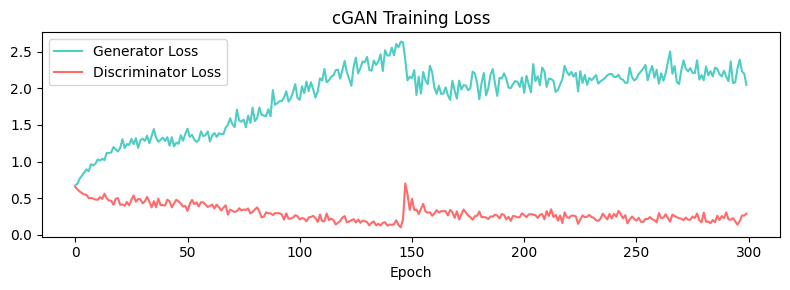

✅ cGAN training complete!

✅ Balanced dataset — Total: 85234 | Stroke: 42617 | No-stroke: 42617


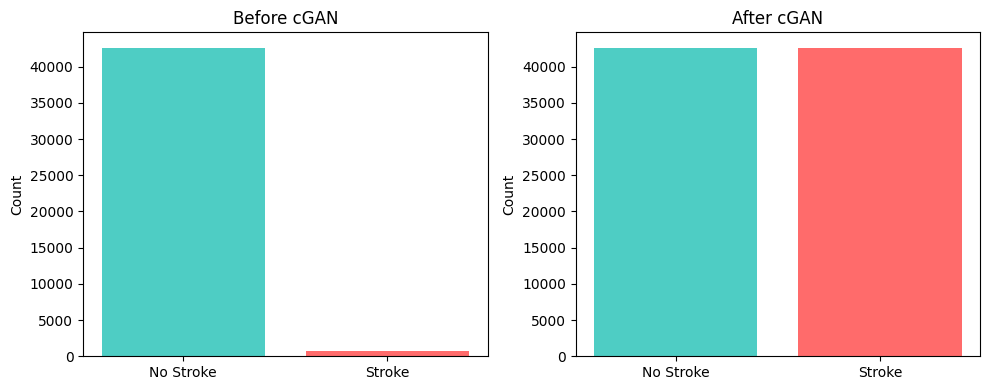


Train: 61580 | Val: 10868 | Test: 12786

🏗️  Model architecture:
HybridStrokeModel(
  (cnn): Sequential(
    (0): CNNBlock(
      (conv1): Conv1d(1, 16, kernel_size=(3,), stride=(1,), padding=(1,))
      (conv2): Conv1d(16, 16, kernel_size=(3,), stride=(1,), padding=(1,))
      (bn1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (bn2): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): GELU(approximate='none')
      (proj): Conv1d(1, 16, kernel_size=(1,), stride=(1,))
    )
    (1): CNNBlock(
      (conv1): Conv1d(16, 32, kernel_size=(3,), stride=(1,), padding=(1,))
      (conv2): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(1,))
      (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): GELU(approximate='none')
      (proj): Conv1d(16, 32, kernel_size=(1,

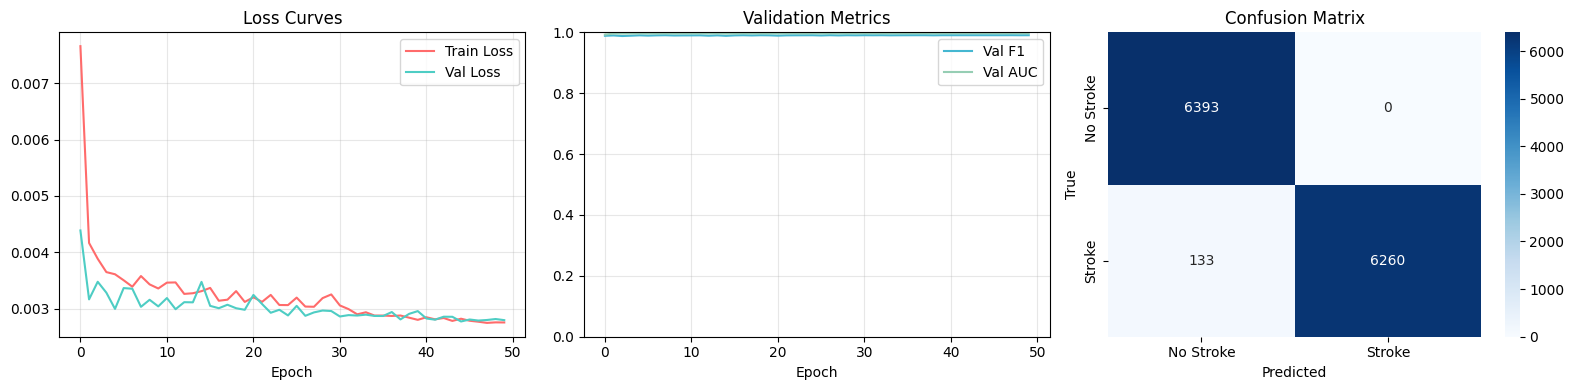


✅ All plots saved. Training complete!


In [14]:
# ============================================================
# 🧠 Advanced Brain Stroke Prediction
# Data Balancing : Conditional GAN + Focal Loss
# Final Model    : CNN + BiLSTM + Transformer Hybrid
# ============================================================

import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ── Core ML ──────────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, f1_score, accuracy_score)

# ── Deep Learning ─────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR

# ── Viz ───────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using device: {device}")


# ============================================================
# SECTION 1 — Load & Preprocess
# ============================================================

data = pd.read_csv("/kaggle/input/cerebral-stroke-predictionimbalaced-dataset/dataset.csv")

print("Shape:", data.shape)
print("\nClass distribution:\n", data['stroke'].value_counts())
print("\nMissing values:\n", data.isnull().sum())

# Encode categoricals
le = LabelEncoder()
for col in data.columns:
    if data[col].dtype == 'object':
        data[col] = le.fit_transform(data[col].astype(str))

# Fill missing
data = data.fillna(data.mean(numeric_only=True))

X = data.drop('stroke', axis=1).values.astype(np.float32)
y = data['stroke'].values.astype(np.float32)

# Scale
scaler = StandardScaler()
X = scaler.fit_transform(X)

print(f"\n✅ Features shape: {X.shape}")
print(f"✅ Positive (stroke) samples: {int(y.sum())} / {len(y)}")


# ============================================================
# SECTION 2 — FOCAL LOSS (plug-in replacement for BCELoss)
# ============================================================
# Focal Loss down-weights easy negatives so the model focuses
# on hard, rare positive (stroke) examples.
# FL(p_t) = -alpha * (1 - p_t)^gamma * log(p_t)

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, reduction='mean'):
        """
        alpha : weight for positive class (tune 0.25-0.75)
        gamma : focusing parameter — higher = more focus on hard examples
        """
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        p_t = torch.exp(-bce)                          # probability of correct class
        focal_weight = self.alpha * (1 - p_t) ** self.gamma
        loss = focal_weight * bce
        return loss.mean() if self.reduction == 'mean' else loss.sum()


# ============================================================
# SECTION 3 — CONDITIONAL GAN FOR TABULAR DATA
# ============================================================
# cGAN generates realistic synthetic minority (stroke=1) samples.
# Generator takes: noise + class label → synthetic feature vector
# Discriminator takes: feature vector + class label → real/fake score

INPUT_DIM = X.shape[1]   # number of features
NOISE_DIM = 64           # latent noise dimension
EMBED_DIM = 8            # label embedding size


class CGANGenerator(nn.Module):
    def __init__(self, noise_dim, output_dim, embed_dim=8):
        super().__init__()
        self.label_embed = nn.Embedding(2, embed_dim)
        self.net = nn.Sequential(
            nn.Linear(noise_dim + embed_dim, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, output_dim),
            nn.Tanh()    # output in [-1, 1] → matches StandardScaler range
        )

    def forward(self, noise, labels):
        label_emb = self.label_embed(labels)          # (B, embed_dim)
        x = torch.cat([noise, label_emb], dim=1)      # (B, noise+embed)
        return self.net(x)


class CGANDiscriminator(nn.Module):
    def __init__(self, input_dim, embed_dim=8):
        super().__init__()
        self.label_embed = nn.Embedding(2, embed_dim)
        self.net = nn.Sequential(
            nn.Linear(input_dim + embed_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(128, 1)    # raw logit — use BCEWithLogitsLoss
        )

    def forward(self, x, labels):
        label_emb = self.label_embed(labels)
        x = torch.cat([x, label_emb], dim=1)
        return self.net(x)


def train_cgan(X_minority, epochs=300, batch_size=64, lr=2e-4, noise_dim=NOISE_DIM):
    """
    Train cGAN on minority class samples only.
    Returns the trained generator.
    """
    print("\n🔄 Training Conditional GAN on minority class...")

    X_t = torch.tensor(X_minority, dtype=torch.float32).to(device)
    labels_t = torch.ones(len(X_minority), dtype=torch.long).to(device)   # all class=1

    dataset = TensorDataset(X_t, labels_t)
    loader  = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)

    G = CGANGenerator(noise_dim, X_minority.shape[1]).to(device)
    D = CGANDiscriminator(X_minority.shape[1]).to(device)

    opt_G = Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
    opt_D = Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))
    criterion = nn.BCEWithLogitsLoss()

    g_losses, d_losses = [], []

    for epoch in range(epochs):
        for real_x, real_y in loader:
            B = real_x.size(0)
            real_labels = torch.ones(B, 1).to(device)
            fake_labels = torch.zeros(B, 1).to(device)

            # ── Train Discriminator ──────────────────────────
            D.zero_grad()
            d_real = D(real_x, real_y)
            loss_d_real = criterion(d_real, real_labels)

            noise = torch.randn(B, noise_dim).to(device)
            fake_y = torch.ones(B, dtype=torch.long).to(device)
            fake_x = G(noise, fake_y).detach()
            d_fake = D(fake_x, fake_y)
            loss_d_fake = criterion(d_fake, fake_labels)

            loss_D = (loss_d_real + loss_d_fake) / 2
            loss_D.backward()
            opt_D.step()

            # ── Train Generator ──────────────────────────────
            G.zero_grad()
            noise = torch.randn(B, noise_dim).to(device)
            fake_x = G(noise, fake_y)
            d_out  = D(fake_x, fake_y)
            loss_G = criterion(d_out, real_labels)   # fool discriminator
            loss_G.backward()
            opt_G.step()

        g_losses.append(loss_G.item())
        d_losses.append(loss_D.item())

        if (epoch + 1) % 50 == 0:
            print(f"  Epoch {epoch+1:3d}/{epochs} | G Loss: {loss_G.item():.4f} | D Loss: {loss_D.item():.4f}")

    # Plot GAN training curve
    plt.figure(figsize=(8, 3))
    plt.plot(g_losses, label='Generator Loss', color='#4ECDC4')
    plt.plot(d_losses, label='Discriminator Loss', color='#FF6B6B')
    plt.title('cGAN Training Loss'); plt.xlabel('Epoch'); plt.legend(); plt.tight_layout()
    plt.savefig('cgan_training.png', dpi=120); plt.show()

    print("✅ cGAN training complete!")
    return G


def generate_synthetic_samples(G, n_samples, noise_dim=NOISE_DIM):
    """Generate n_samples synthetic minority class samples."""
    G.eval()
    with torch.no_grad():
        noise  = torch.randn(n_samples, noise_dim).to(device)
        labels = torch.ones(n_samples, dtype=torch.long).to(device)
        synth  = G(noise, labels).cpu().numpy()
    return synth


# ── Run cGAN ─────────────────────────────────────────────────
X_minority = X[y == 1]
X_majority = X[y == 0]
n_to_generate = len(X_majority) - len(X_minority)

G = train_cgan(X_minority, epochs=300)
X_synth = generate_synthetic_samples(G, n_to_generate)

# Combine real + synthetic
X_balanced = np.vstack([X, X_synth])
y_balanced  = np.concatenate([y, np.ones(n_to_generate)])

print(f"\n✅ Balanced dataset — Total: {len(y_balanced)} | Stroke: {int(y_balanced.sum())} | No-stroke: {int((y_balanced==0).sum())}")

# Visualise balance
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (vals, title) in zip(axes, [(y, 'Before cGAN'), (y_balanced, 'After cGAN')]):
    counts = pd.Series(vals).value_counts().sort_index()
    ax.bar(['No Stroke', 'Stroke'], counts.values, color=['#4ECDC4', '#FF6B6B'])
    ax.set_title(title); ax.set_ylabel('Count')
plt.tight_layout(); plt.savefig('class_balance.png', dpi=120); plt.show()


# ============================================================
# SECTION 4 — TRAIN / VAL / TEST SPLIT
# ============================================================

X_temp, X_test, y_temp, y_test = train_test_split(
    X_balanced, y_balanced, test_size=0.15, random_state=SEED, stratify=y_balanced)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.15, random_state=SEED, stratify=y_temp)

print(f"\nTrain: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")

def to_loader(X, y, batch_size=64, shuffle=True):
    # Reshape to (B, 1, features) → treat feature vector as a 1-step sequence
    X_t = torch.tensor(X, dtype=torch.float32).unsqueeze(1)  # (B, seq=1, features)
    y_t = torch.tensor(y, dtype=torch.float32)
    return DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=shuffle)

train_loader = to_loader(X_train, y_train)
val_loader   = to_loader(X_val,   y_val,   shuffle=False)
test_loader  = to_loader(X_test,  y_test,  shuffle=False)


# ============================================================
# SECTION 5 — HYBRID MODEL: CNN + BiLSTM + TRANSFORMER
# ============================================================
#
# Architecture pipeline:
#
#  Input (B, 1, F)
#      │
#  ┌───▼────────────────────────────────────────┐
#  │  CNN Block                                  │
#  │  Conv1d → BN → GELU → Conv1d → BN → GELU  │
#  │  → residual add → output (B, C, F)         │
#  └───────────────────────────────────────────┘
#      │  reshape → (B, F, C)
#  ┌───▼────────────────────────────────────────┐
#  │  BiLSTM Block                               │
#  │  2-layer bidirectional LSTM                 │
#  │  → output (B, F, 2*hidden)                 │
#  └───────────────────────────────────────────┘
#      │
#  ┌───▼────────────────────────────────────────┐
#  │  Transformer Encoder Block                  │
#  │  Multi-head Self-Attention + FFN + LN       │
#  │  → global average pool → (B, d_model)      │
#  └───────────────────────────────────────────┘
#      │
#  ┌───▼──────────────────┐
#  │  Classifier Head      │
#  │  Linear → GELU → Drop│
#  │  → Linear → logit    │
#  └──────────────────────┘


class CNNBlock(nn.Module):
    """Local feature extractor across the feature dimension."""
    def __init__(self, in_channels, out_channels, kernel_size=3):
        super().__init__()
        pad = kernel_size // 2
        self.conv1 = nn.Conv1d(in_channels,  out_channels, kernel_size, padding=pad)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size, padding=pad)
        self.bn1   = nn.BatchNorm1d(out_channels)
        self.bn2   = nn.BatchNorm1d(out_channels)
        self.act   = nn.GELU()
        # residual projection if channel dims differ
        self.proj  = nn.Conv1d(in_channels, out_channels, 1) if in_channels != out_channels else nn.Identity()

    def forward(self, x):
        # x: (B, C, L)
        residual = self.proj(x)
        x = self.act(self.bn1(self.conv1(x)))
        x = self.bn2(self.conv2(x))
        return self.act(x + residual)


class BiLSTMBlock(nn.Module):
    """Temporal / sequential dependency capture."""
    def __init__(self, input_size, hidden_size, num_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size, hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x: (B, seq, features)
        out, _ = self.lstm(x)   # out: (B, seq, 2*hidden)
        return self.dropout(out)


class TransformerBlock(nn.Module):
    """Global dependency and attention-based weighting."""
    def __init__(self, d_model, nhead=4, dim_feedforward=256, dropout=0.1):
        super().__init__()
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True,
            activation='gelu'
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=2)

    def forward(self, x):
        # x: (B, seq, d_model)
        out = self.encoder(x)          # (B, seq, d_model)
        return out.mean(dim=1)         # global average pool → (B, d_model)


class HybridStrokeModel(nn.Module):
    """CNN + BiLSTM + Transformer hybrid for tabular stroke prediction."""

    def __init__(self, input_features, cnn_channels=32, lstm_hidden=64,
                 transformer_dim=128, dropout=0.3):
        super().__init__()

        # ── CNN ─────────────────────────────────────────────
        # Input treated as (B, 1, F) — 1 channel, F "time steps"
        self.cnn = nn.Sequential(
            CNNBlock(1, cnn_channels // 2),
            CNNBlock(cnn_channels // 2, cnn_channels),
        )

        # ── BiLSTM ──────────────────────────────────────────
        # After CNN: (B, cnn_channels, F) → permute → (B, F, cnn_channels)
        self.bilstm = BiLSTMBlock(cnn_channels, lstm_hidden, num_layers=2, dropout=dropout)

        # ── Projection to transformer dim ────────────────────
        self.proj = nn.Linear(2 * lstm_hidden, transformer_dim)

        # ── Transformer ─────────────────────────────────────
        self.transformer = TransformerBlock(transformer_dim, nhead=4,
                                            dim_feedforward=256, dropout=dropout)

        # ── Classifier head ─────────────────────────────────
        self.classifier = nn.Sequential(
            nn.Linear(transformer_dim, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)   # raw logit
        )

    def forward(self, x):
        # x: (B, 1, F)
        x = self.cnn(x)                # (B, cnn_channels, F)
        x = x.permute(0, 2, 1)        # (B, F, cnn_channels)
        x = self.bilstm(x)             # (B, F, 2*lstm_hidden)
        x = self.proj(x)               # (B, F, transformer_dim)
        x = self.transformer(x)        # (B, transformer_dim)
        return self.classifier(x).squeeze(-1)  # (B,)


model = HybridStrokeModel(
    input_features=INPUT_DIM,
    cnn_channels=32,
    lstm_hidden=64,
    transformer_dim=128,
    dropout=0.3
).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n🏗️  Model architecture:\n{model}")
print(f"\n✅ Total trainable parameters: {total_params:,}")


# ============================================================
# SECTION 6 — TRAINING WITH FOCAL LOSS
# ============================================================

criterion = FocalLoss(alpha=0.25, gamma=2.0)
optimizer = Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-5)

EPOCHS = 50
best_val_f1  = 0
best_weights = None
history = {'train_loss': [], 'val_loss': [], 'val_f1': [], 'val_auc': []}


def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, all_preds, all_labels = 0, [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for X_b, y_b in loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            logits = model(X_b)
            loss   = criterion(logits, y_b)
            if train:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
            total_loss  += loss.item()
            probs = torch.sigmoid(logits).detach().cpu().numpy()
            all_preds.extend(probs)
            all_labels.extend(y_b.cpu().numpy())
    preds_bin = (np.array(all_preds) > 0.5).astype(int)
    f1  = f1_score(all_labels, preds_bin, zero_division=0)
    auc = roc_auc_score(all_labels, all_preds)
    return total_loss / len(loader), f1, auc


print("\n🚀 Training Hybrid CNN+BiLSTM+Transformer with Focal Loss...\n")
for epoch in range(1, EPOCHS + 1):
    train_loss, train_f1, _     = run_epoch(train_loader, train=True)
    val_loss,   val_f1,  val_auc = run_epoch(val_loader,   train=False)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_f1'].append(val_f1)
    history['val_auc'].append(val_auc)

    # Save best model
    if val_f1 > best_val_f1:
        best_val_f1  = val_f1
        best_weights = {k: v.clone() for k, v in model.state_dict().items()}

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{EPOCHS} | Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val F1: {val_f1:.4f} | Val AUC: {val_auc:.4f}")

print(f"\n✅ Best Val F1: {best_val_f1:.4f}")
model.load_state_dict(best_weights)


# ============================================================
# SECTION 7 — EVALUATION
# ============================================================

model.eval()
all_preds, all_probs, all_labels = [], [], []
with torch.no_grad():
    for X_b, y_b in test_loader:
        logits = model(X_b.to(device))
        probs  = torch.sigmoid(logits).cpu().numpy()
        preds  = (probs > 0.5).astype(int)
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(y_b.numpy())

print("\n" + "="*55)
print("📊 FINAL TEST RESULTS")
print("="*55)
print(f"Accuracy  : {accuracy_score(all_labels, all_preds):.4f}")
print(f"F1 Score  : {f1_score(all_labels, all_preds):.4f}")
print(f"ROC-AUC   : {roc_auc_score(all_labels, all_probs):.4f}")
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=['No Stroke', 'Stroke']))


# ── Plots ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Training curves
axes[0].plot(history['train_loss'], label='Train Loss', color='#FF6B6B')
axes[0].plot(history['val_loss'],   label='Val Loss',   color='#4ECDC4')
axes[0].set_title('Loss Curves'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history['val_f1'],  label='Val F1',  color='#45B7D1')
axes[1].plot(history['val_auc'], label='Val AUC', color='#96CEB4')
axes[1].set_title('Validation Metrics'); axes[1].set_xlabel('Epoch')
axes[1].set_ylim(0, 1); axes[1].legend(); axes[1].grid(alpha=0.3)

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=['No Stroke', 'Stroke'],
            yticklabels=['No Stroke', 'Stroke'])
axes[2].set_title('Confusion Matrix')
axes[2].set_ylabel('True'); axes[2].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('results.png', dpi=120)
plt.show()

print("\n✅ All plots saved. Training complete!")